In [1]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.metrics import f1_score, classification_report
from scipy.stats import pearsonr

from transformers import (
    AutoModelForSequenceClassification,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    RobertaConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback,
    EarlyStoppingCallback
)



In [2]:
# =========================================================
# 2. GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive", exist_ok=True)

LOG_FILE_STEP1 = "/content/drive/MyDrive/RoBERTa_Hierarchical_Step1.csv"
LOG_FILE_STEP2 = "/content/drive/MyDrive/RoBERTa_Hierarchical_Step2.csv"
FINAL_PRED_FILE = "/content/drive/MyDrive/RoBERTa_Hierarchical_Final_Predictions.csv"

# clean one-row-per-epoch header for Step 1
with open(LOG_FILE_STEP1, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "test_loss",
        "val_f1_macro",
        "test_f1_macro",
        "val_f1_micro",
        "test_f1_micro",
        "val_pearson",
        "test_pearson"
    ])

# clean one-row-per-epoch header for Step 2
with open(LOG_FILE_STEP2, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "test_loss",
        "val_f1_macro",
        "test_f1_macro",
        "val_f1_micro",
        "test_f1_micro",
        "val_pearson",
        "test_pearson"
    ])

print("Step 1 log file:", LOG_FILE_STEP1)
print("Step 2 log file:", LOG_FILE_STEP2)



Mounted at /content/drive
Step 1 log file: /content/drive/MyDrive/RoBERTa_Hierarchical_Step1.csv
Step 2 log file: /content/drive/MyDrive/RoBERTa_Hierarchical_Step2.csv


In [3]:
# =========================================================
# 3. SEED + DEVICE
# =========================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [4]:
# =========================================================
# 4. LABELS
# =========================================================
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
INTENSITY_COLUMNS = [f"{emotion}_intensity" for emotion in EMOTIONS]

# =========================================================
# 5. LOAD DATASET
# =========================================================
train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data   = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data  = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("Original sizes:")
print({
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df)
})

# =========================================================
# 6. PREPARE TWO-STEP DATA
# =========================================================
def prepare_two_step_data(df):
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    for emotion in EMOTIONS:
        df[f"{emotion}_intensity"] = df[emotion].astype(int)

    for emotion in EMOTIONS:
        df[emotion] = (df[f"{emotion}_intensity"] > 0).astype(int)

    return df

train_two = prepare_two_step_data(train_df)
val_two   = prepare_two_step_data(val_df)
test_two  = prepare_two_step_data(test_df)

# =========================================================
# 7. TRUE 70/20/10 SPLIT
# =========================================================
full_df = pd.concat([train_two, val_two, test_two], ignore_index=True)
full_df = full_df[["text"] + EMOTIONS + INTENSITY_COLUMNS]
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(full_df)
train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_split = full_df[:train_end].reset_index(drop=True)
val_split   = full_df[train_end:val_end].reset_index(drop=True)
test_split  = full_df[val_end:].reset_index(drop=True)

print("New split sizes:")
print({
    "train": len(train_split),
    "val": len(val_split),
    "test": len(test_split)
})

# =========================================================
# 8. STEP 1 DATA (EMOTION PRESENCE)
# =========================================================
train_step1_df = train_split[["text"] + EMOTIONS].copy()
val_step1_df   = val_split[["text"] + EMOTIONS].copy()
test_step1_df  = test_split[["text"] + EMOTIONS].copy()

# =========================================================
# 9. STEP 2 DATA (INTENSITY PREDICTION)
# =========================================================
train_step2_df = train_split[["text"] + INTENSITY_COLUMNS].copy()
val_step2_df   = val_split[["text"] + INTENSITY_COLUMNS].copy()
test_step2_df  = test_split[["text"] + INTENSITY_COLUMNS].copy()

# =========================================================
# 10. CONVERT TO HF DATASETS
# =========================================================
train_step1_ds = Dataset.from_pandas(train_step1_df, preserve_index=False)
val_step1_ds   = Dataset.from_pandas(val_step1_df, preserve_index=False)
test_step1_ds  = Dataset.from_pandas(test_step1_df, preserve_index=False)

train_step2_ds = Dataset.from_pandas(train_step2_df, preserve_index=False)
val_step2_ds   = Dataset.from_pandas(val_step2_df, preserve_index=False)
test_step2_ds  = Dataset.from_pandas(test_step2_df, preserve_index=False)

# =========================================================
# 11. TOKENIZER
# =========================================================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_step1_ds = train_step1_ds.map(tokenize_function, batched=True)
val_step1_ds   = val_step1_ds.map(tokenize_function, batched=True)
test_step1_ds  = test_step1_ds.map(tokenize_function, batched=True)

train_step2_ds = train_step2_ds.map(tokenize_function, batched=True)
val_step2_ds   = val_step2_ds.map(tokenize_function, batched=True)
test_step2_ds  = test_step2_ds.map(tokenize_function, batched=True)

# =========================================================
# 12. ADD LABELS
# =========================================================
def add_step1_labels(example):
    example["labels"] = [float(example[emotion]) for emotion in EMOTIONS]
    return example

def add_step2_labels(example):
    example["labels"] = [int(example[col]) for col in INTENSITY_COLUMNS]
    return example

train_step1_ds = train_step1_ds.map(add_step1_labels)
val_step1_ds   = val_step1_ds.map(add_step1_labels)
test_step1_ds  = test_step1_ds.map(add_step1_labels)

train_step2_ds = train_step2_ds.map(add_step2_labels)
val_step2_ds   = val_step2_ds.map(add_step2_labels)
test_step2_ds  = test_step2_ds.map(add_step2_labels)

# =========================================================
# 13. FORMAT
# =========================================================
train_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

eng/test-00000-of-00001.parquet:   0%|          | 0.00/182k [00:00<?, ?B/s]

...

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

In [5]:
# =========================================================
# 14. METRIC HELPERS
# =========================================================
def safe_pearson(x, y):
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0
    r, _ = pearsonr(x, y)
    return 0.0 if np.isnan(r) else float(r)



In [6]:
# =========================================================
# 15. STEP 1 MODEL
# =========================================================
model_step1 = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(EMOTIONS),
    problem_type="multi_label_classification"
).to(device)

# =========================================================
# 16. STEP 1 METRICS
# =========================================================
def compute_metrics_step1(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(labels, preds, average="macro", zero_division=0)
    f1_micro = f1_score(labels, preds, average="micro", zero_division=0)

    pearsons = []
    for i in range(labels.shape[1]):
        pearsons.append(safe_pearson(labels[:, i], probs[:, i]))
    pearson_mean = float(np.mean(pearsons))

    return {
        "f1_macro": float(f1_macro),
        "f1_micro": float(f1_micro),
        "pearson": float(pearson_mean)
    }

# =========================================================
# 17. STEP 1 PLOT LISTS
# =========================================================
step1_epoch_list = []
step1_train_loss_list = []

step1_val_loss_list = []
step1_val_f1_macro_list = []
step1_val_f1_micro_list = []
step1_val_pearson_list = []

step1_test_loss_list = []
step1_test_f1_macro_list = []
step1_test_f1_micro_list = []
step1_test_pearson_list = []

# =========================================================
# 18. STEP 1 CALLBACK
# =========================================================
class SaveMetricsCallbackStep1(TrainerCallback):
    def __init__(self, file_path, test_dataset):
        self.file_path = file_path
        self.test_dataset = test_dataset
        self.current_train_loss = None
        self.trainer_ref = None
        self._inside_test_eval = False

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        if self._inside_test_eval:
            return

        epoch = float(metrics.get("epoch", state.epoch))
        train_loss = self.current_train_loss if self.current_train_loss is not None else ""

        val_loss = float(metrics.get("eval_loss", 0.0))
        val_f1_macro = float(metrics.get("eval_f1_macro", 0.0))
        val_f1_micro = float(metrics.get("eval_f1_micro", 0.0))
        val_pearson = float(metrics.get("eval_pearson", 0.0))

        test_loss = ""
        test_f1_macro = ""
        test_f1_micro = ""
        test_pearson = ""

        if self.trainer_ref is not None:
            self._inside_test_eval = True
            test_results = self.trainer_ref.evaluate(
                eval_dataset=self.test_dataset,
                metric_key_prefix="test"
            )
            self._inside_test_eval = False

            test_loss = float(test_results.get("test_loss", 0.0))
            test_f1_macro = float(test_results.get("test_f1_macro", 0.0))
            test_f1_micro = float(test_results.get("test_f1_micro", 0.0))
            test_pearson = float(test_results.get("test_pearson", 0.0))

            step1_test_loss_list.append(test_loss)
            step1_test_f1_macro_list.append(test_f1_macro)
            step1_test_f1_micro_list.append(test_f1_micro)
            step1_test_pearson_list.append(test_pearson)

        step1_epoch_list.append(epoch)
        step1_train_loss_list.append(train_loss)

        step1_val_loss_list.append(val_loss)
        step1_val_f1_macro_list.append(val_f1_macro)
        step1_val_f1_micro_list.append(val_f1_micro)
        step1_val_pearson_list.append(val_pearson)

        with open(self.file_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch,
                train_loss,
                val_loss,
                test_loss,
                val_f1_macro,
                test_f1_macro,
                val_f1_micro,
                test_f1_micro,
                val_pearson,
                test_pearson
            ])

# =========================================================
# 19. STEP 1 TRAINING ARGS
# =========================================================
training_args_step1 = TrainingArguments(
    output_dir="/content/roberta_step1_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================================================
# 20. STEP 1 TRAINER
# =========================================================
callback_step1 = SaveMetricsCallbackStep1(LOG_FILE_STEP1, test_step1_ds)

trainer_step1 = Trainer(
    model=model_step1,
    args=training_args_step1,
    train_dataset=train_step1_ds,
    eval_dataset=val_step1_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_step1,
    callbacks=[callback_step1]
)

callback_step1.trainer_ref = trainer_step1

# =========================================================
# 21. TRAIN STEP 1
# =========================================================
print("\nStarting Step 1: Emotion Detection")
start1 = time.time()
trainer_step1.train()
end1 = time.time()
print(f"Step 1 training time: {end1 - start1:.1f} seconds")

# =========================================================
# 22. STEP 1 FINAL TEST + CLASSWISE
# =========================================================
final_step1_test_results = trainer_step1.evaluate(
    eval_dataset=test_step1_ds,
    metric_key_prefix="test"
)

print("\nFinal Step 1 Test Results:")
for key, value in final_step1_test_results.items():
    print(f"{key}: {value}")

pred_step1_final = trainer_step1.predict(test_step1_ds)
logits_step1_final = pred_step1_final.predictions
labels_step1_final = pred_step1_final.label_ids

probs_step1_final = 1 / (1 + np.exp(-logits_step1_final))
preds_step1_final = (probs_step1_final >= 0.5).astype(int)

report_step1 = classification_report(
    labels_step1_final,
    preds_step1_final,
    target_names=EMOTIONS,
    zero_division=0,
    output_dict=True
)

with open(LOG_FILE_STEP1, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([])
    writer.writerow(["CLASSWISE RESULTS"])
    writer.writerow(["class", "precision", "recall", "f1_score", "support"])

    for class_name in EMOTIONS:
        row = report_step1.get(class_name, {})
        writer.writerow([
            class_name,
            row.get("precision", ""),
            row.get("recall", ""),
            row.get("f1-score", ""),
            row.get("support", "")
        ])



config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting Step 1: Emotion Detection


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Step 1 training time: 634.6 seconds



Final Step 1 Test Results:
test_loss: 0.4618426561355591
test_f1_macro: 0.7227215607753756
test_f1_micro: 0.7607081667618504
test_pearson: 0.642016613483429
test_runtime: 2.6636
test_samples_per_second: 212.12
test_steps_per_second: 53.312
epoch: 10.0


In [7]:
# =========================================================
# 23. STEP 2 MODEL
# =========================================================
class RobertaForMultiEmotionIntensity(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_emotions = len(EMOTIONS)
        self.num_classes = 4  # 0,1,2,3

        self.roberta = AutoModelForSequenceClassification.from_pretrained(
            "roberta-base",
            config=config
        )

        self.classifier = nn.Linear(config.hidden_size, self.num_emotions * self.num_classes)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, input_ids=None, attention_mask=None, labels=None, emotion_predictions=None, **kwargs):
        outputs = self.roberta.roberta(input_ids=input_ids, attention_mask=attention_mask)

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        logits = self.classifier(cls_output)
        logits = logits.view(-1, self.num_emotions, self.num_classes)

        if emotion_predictions is not None:
            emotion_predictions = emotion_predictions.unsqueeze(-1).expand(-1, -1, self.num_classes)
            logits = logits * emotion_predictions

        loss = None
        if labels is not None:
            labels = labels.long()
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_classes), labels.view(-1))

        return {"loss": loss, "logits": logits}

config = RobertaConfig.from_pretrained("roberta-base")
model_step2 = RobertaForMultiEmotionIntensity(config=config).to(device)

print("\nCustom model for Step 2 initialized successfully!")

# =========================================================
# 24. STEP 2 METRICS
# =========================================================
def compute_metrics_step2(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    f1_macro = f1_score(
        labels.reshape(-1),
        preds.reshape(-1),
        average="macro",
        zero_division=0
    )

    f1_micro = f1_score(
        labels.reshape(-1),
        preds.reshape(-1),
        average="micro",
        zero_division=0
    )

    pearson = safe_pearson(labels.reshape(-1), preds.reshape(-1))

    return {
        "f1_macro": float(f1_macro),
        "f1_micro": float(f1_micro),
        "pearson": float(pearson)
    }

# =========================================================
# 25. STEP 2 PLOT LISTS
# =========================================================
step2_epoch_list = []
step2_train_loss_list = []

step2_val_loss_list = []
step2_val_f1_macro_list = []
step2_val_f1_micro_list = []
step2_val_pearson_list = []

step2_test_loss_list = []
step2_test_f1_macro_list = []
step2_test_f1_micro_list = []
step2_test_pearson_list = []

# =========================================================
# 26. STEP 2 CALLBACK
# =========================================================
class SaveMetricsCallbackStep2(TrainerCallback):
    def __init__(self, file_path, test_dataset):
        self.file_path = file_path
        self.test_dataset = test_dataset
        self.current_train_loss = None
        self.trainer_ref = None
        self._inside_test_eval = False

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        if self._inside_test_eval:
            return

        epoch = float(metrics.get("epoch", state.epoch))
        train_loss = self.current_train_loss if self.current_train_loss is not None else ""

        val_loss = float(metrics.get("eval_loss", 0.0))
        val_f1_macro = float(metrics.get("eval_f1_macro", 0.0))
        val_f1_micro = float(metrics.get("eval_f1_micro", 0.0))
        val_pearson = float(metrics.get("eval_pearson", 0.0))

        test_loss = ""
        test_f1_macro = ""
        test_f1_micro = ""
        test_pearson = ""

        if self.trainer_ref is not None:
            self._inside_test_eval = True
            test_results = self.trainer_ref.evaluate(
                eval_dataset=self.test_dataset,
                metric_key_prefix="test"
            )
            self._inside_test_eval = False

            test_loss = float(test_results.get("test_loss", 0.0))
            test_f1_macro = float(test_results.get("test_f1_macro", 0.0))
            test_f1_micro = float(test_results.get("test_f1_micro", 0.0))
            test_pearson = float(test_results.get("test_pearson", 0.0))

            step2_test_loss_list.append(test_loss)
            step2_test_f1_macro_list.append(test_f1_macro)
            step2_test_f1_micro_list.append(test_f1_micro)
            step2_test_pearson_list.append(test_pearson)

        step2_epoch_list.append(epoch)
        step2_train_loss_list.append(train_loss)

        step2_val_loss_list.append(val_loss)
        step2_val_f1_macro_list.append(val_f1_macro)
        step2_val_f1_micro_list.append(val_f1_micro)
        step2_val_pearson_list.append(val_pearson)

        with open(self.file_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch,
                train_loss,
                val_loss,
                test_loss,
                val_f1_macro,
                test_f1_macro,
                val_f1_micro,
                test_f1_micro,
                val_pearson,
                test_pearson
            ])

# =========================================================
# 27. STEP 2 TRAINING ARGS
# =========================================================
training_args_step2 = TrainingArguments(
    output_dir="/content/roberta_step2_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================================================
# 28. STEP 2 TRAINER
# =========================================================
callback_step2 = SaveMetricsCallbackStep2(LOG_FILE_STEP2, test_step2_ds)

trainer_step2 = Trainer(
    model=model_step2,
    args=training_args_step2,
    train_dataset=train_step2_ds,
    eval_dataset=val_step2_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_step2,
    callbacks=[callback_step2]
)

callback_step2.trainer_ref = trainer_step2

# =========================================================
# 29. TRAIN STEP 2
# =========================================================
print("\nStarting Step 2: Intensity Classification")
start2 = time.time()
trainer_step2.train()
end2 = time.time()
print(f"Step 2 training time: {end2 - start2:.1f} seconds")





Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Custom model for Step 2 initialized successfully!

Starting Step 2: Intensity Classification


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Pearson
1,0.731192,0.610464,0.517205,0.750355,0.677440
2,0.536864,0.589709,0.576643,0.758156,0.729729
3,0.427598,0.578761,0.570440,0.772872,0.741658
4,0.341755,0.601528,0.576909,0.775532,0.756107
5,0.274592,0.643784,0.589822,0.769681,0.757497
6,0.219552,0.684874,0.598433,0.766312,0.760978
7,0.175839,0.724845,0.597374,0.772163,0.758129
8,0.142951,0.748936,0.599924,0.771809,0.760460
9,0.119113,0.768347,0.601992,0.774823,0.765192
10,0.099168,0.778410,0.602937,0.773936,0.766987


Step 2 training time: 814.5 seconds


In [8]:
# =========================================================
# 29. FINAL COMBINED TWO-STEP PREDICTION
# =========================================================
print("\nCreating final combined two-step predictions...")

pred_step1 = trainer_step1.predict(test_step1_ds)
logits_step1 = pred_step1.predictions
true_emotions = pred_step1.label_ids

probs_step1 = 1 / (1 + np.exp(-logits_step1))
pred_emotions = (probs_step1 >= 0.5).astype(int)

pred_step2 = trainer_step2.predict(test_step2_ds)
logits_step2 = pred_step2.predictions
true_intensities = pred_step2.label_ids

pred_intensities = np.argmax(logits_step2, axis=-1)

final_pred_intensities = pred_intensities * pred_emotions

# =========================================================
# 30. FINAL COMBINED EVALUATION
# =========================================================
true_flat = true_intensities.reshape(-1)
pred_flat = final_pred_intensities.reshape(-1)

final_macro_f1 = f1_score(
    true_flat,
    pred_flat,
    average="macro",
    zero_division=0
)

final_micro_f1 = f1_score(
    true_flat,
    pred_flat,
    average="micro",
    zero_division=0
)

exact_match_accuracy = np.all(
    true_intensities == final_pred_intensities,
    axis=1
).mean()

if np.std(true_flat) == 0 or np.std(pred_flat) == 0:
    final_pearson = 0.0
else:
    final_pearson, _ = pearsonr(true_flat, pred_flat)
    if np.isnan(final_pearson):
        final_pearson = 0.0

print("\nFINAL COMBINED TWO-STEP RESULTS")
print("--------------------------------")
print("Final Combined Macro F1:", final_macro_f1)
print("Final Combined Micro F1:", final_micro_f1)
print("Final Combined Pearson:", final_pearson)
print("Exact Match Accuracy:", exact_match_accuracy)

# =========================================================
# 31. APPEND FINAL COMBINED RESULTS TO STEP 2 LOG
# =========================================================
with open(FINAL_PRED_FILE, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([])
    writer.writerow(["FINAL COMBINED TWO-STEP RESULTS"])
    writer.writerow(["metric", "value"])
    writer.writerow(["final_macro_f1", final_macro_f1])
    writer.writerow(["final_micro_f1", final_micro_f1])
    writer.writerow(["final_pearson", final_pearson])
    writer.writerow(["exact_match_accuracy", exact_match_accuracy])

# =========================================================
# 32. CLASS-WISE FINAL COMBINED RESULTS
# =========================================================
report_dict = classification_report(
    true_flat,
    pred_flat,
    labels=[0, 1, 2, 3],
    target_names=["0_absent", "1_low", "2_medium", "3_high"],
    zero_division=0,
    output_dict=True
)

with open(LOG_FILE_STEP2, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([])
    writer.writerow(["CLASSWISE FINAL COMBINED RESULTS"])
    writer.writerow(["class", "precision", "recall", "f1_score", "support"])

    for class_name in ["0_absent", "1_low", "2_medium", "3_high"]:
        row = report_dict[class_name]
        writer.writerow([
            class_name,
            row["precision"],
            row["recall"],
            row["f1-score"],
            row["support"]
        ])

print("\nClass-wise final combined results added to Step 2 log.")

# =========================================================
# 33. SAVE FINAL PREDICTIONS CSV
# =========================================================
final_predictions_df = pd.DataFrame({
    "text": test_split["text"],

    "true_anger": true_intensities[:, 0],
    "true_fear": true_intensities[:, 1],
    "true_joy": true_intensities[:, 2],
    "true_sadness": true_intensities[:, 3],
    "true_surprise": true_intensities[:, 4],

    "step1_pred_anger_present": pred_emotions[:, 0],
    "step1_pred_fear_present": pred_emotions[:, 1],
    "step1_pred_joy_present": pred_emotions[:, 2],
    "step1_pred_sadness_present": pred_emotions[:, 3],
    "step1_pred_surprise_present": pred_emotions[:, 4],

    "step2_pred_anger_intensity": pred_intensities[:, 0],
    "step2_pred_fear_intensity": pred_intensities[:, 1],
    "step2_pred_joy_intensity": pred_intensities[:, 2],
    "step2_pred_sadness_intensity": pred_intensities[:, 3],
    "step2_pred_surprise_intensity": pred_intensities[:, 4],

    "final_pred_anger": final_pred_intensities[:, 0],
    "final_pred_fear": final_pred_intensities[:, 1],
    "final_pred_joy": final_pred_intensities[:, 2],
    "final_pred_sadness": final_pred_intensities[:, 3],
    "final_pred_surprise": final_pred_intensities[:, 4],
})

final_predictions_df.to_csv(FINAL_PRED_FILE, index=False)

print("Final combined predictions saved at:", FINAL_PRED_FILE)


Creating final combined two-step predictions...



FINAL COMBINED TWO-STEP RESULTS
--------------------------------
Final Combined Macro F1: 0.5863610083356932
Final Combined Micro F1: 0.7794690265486726
Final Combined Pearson: 0.7651256438534021
Exact Match Accuracy: 0.30796460176991153

Class-wise final combined results added to Step 2 log.
Final combined predictions saved at: /content/drive/MyDrive/RoBERTa_Hierarchical_Final_Predictions.csv


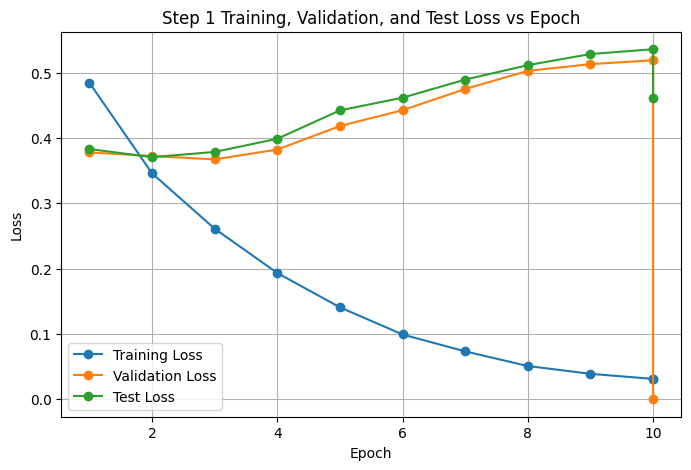

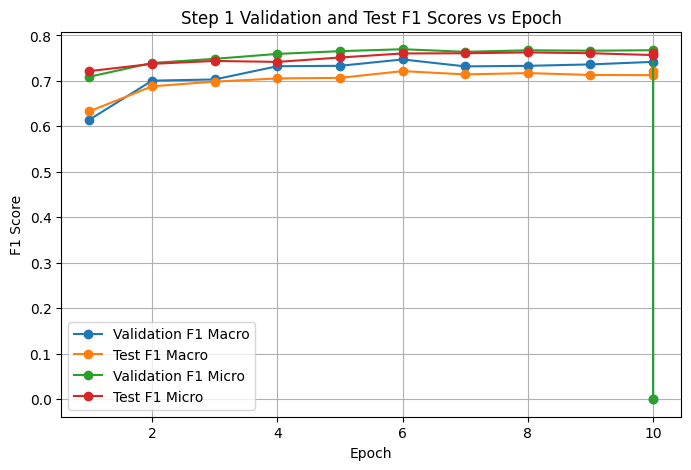

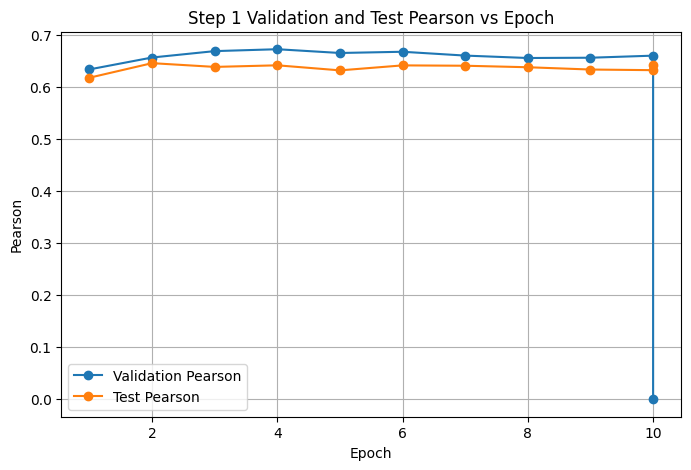

In [9]:
# =========================================================
# 32. STEP 1 PLOTS
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(step1_epoch_list, step1_train_loss_list, marker="o", label="Training Loss")
plt.plot(step1_epoch_list, step1_val_loss_list, marker="o", label="Validation Loss")
plt.plot(step1_epoch_list[:len(step1_test_loss_list)], step1_test_loss_list, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Step 1 Training, Validation, and Test Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step1_epoch_list, step1_val_f1_macro_list, marker="o", label="Validation F1 Macro")
plt.plot(step1_epoch_list[:len(step1_test_f1_macro_list)], step1_test_f1_macro_list, marker="o", label="Test F1 Macro")
plt.plot(step1_epoch_list, step1_val_f1_micro_list, marker="o", label="Validation F1 Micro")
plt.plot(step1_epoch_list[:len(step1_test_f1_micro_list)], step1_test_f1_micro_list, marker="o", label="Test F1 Micro")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Step 1 Validation and Test F1 Scores vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step1_epoch_list, step1_val_pearson_list, marker="o", label="Validation Pearson")
plt.plot(step1_epoch_list[:len(step1_test_pearson_list)], step1_test_pearson_list, marker="o", label="Test Pearson")
plt.xlabel("Epoch")
plt.ylabel("Pearson")
plt.title("Step 1 Validation and Test Pearson vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================